# Part 2 : Non-linear regression

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from datetime import datetime
from copy import deepcopy # Nécessaire pour les boucles de feature selection

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error, mean_squared_error
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Loading files

In [2]:
X_train = pd.read_csv('../data/data_labeled/X_train.csv')
y_train = pd.read_csv('../data/data_labeled/y_train.csv', header=None, names=['risk'])
X_test = pd.read_csv('../data/data_labeled/X_test.csv')
y_test = pd.read_csv('../data/data_labeled/y_test.csv', header=None, names=['risk'])
X_unlabeled = pd.read_csv('../data/data_unlabeled/X.csv')

print(f"Dataset: {X_train.shape[0]} train samples, {X_test.shape[0]} test samples")

Dataset: 1000 train samples, 500 test samples


## Preprocessing

In [3]:
drop_cols = ['img_filename']
num_cols = ['age', 'blood pressure', 'calcium', 'cholesterol', 'hemoglobin', 
            'height', 'potassium', 'vitamin D', 'weight']
nom_cols = ['profession']
ord_cols = ['sarsaparilla', 'smurfberry liquor', 'smurfin donuts']
ord_categories = [
    ['Very low', 'Low', 'Moderate', 'High', 'Very high'],
    ['Very low', 'Low', 'Moderate', 'High', 'Very high'],
    ['Very low', 'Low', 'Moderate', 'High', 'Very high']
]

# Pipeline de preprocessing (sans encodage de la target et sans SFS)
num_transformer = Pipeline(steps=[('scaler', StandardScaler())])
ord_transformer = Pipeline(steps=[('ordinal', OrdinalEncoder(categories=ord_categories))])
nom_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('ord', ord_transformer, ord_cols),
        ('nom', nom_transformer, nom_cols),
        ('drop', 'drop', drop_cols)
    ],
    remainder='passthrough'
)

best_k = 18 # essayer 11

print(f"Preprocessing défini (18 features au total après OHE de 'profession').")
print(f"Application du résultat SFS de Part 1: k={best_k} features.")

Preprocessing défini (18 features au total après OHE de 'profession').
Application du résultat SFS de Part 1: k=18 features.


## Chargement baseline (modèle linéaire)

In [4]:
linear_model_path = '../results/models/linear_model_ridge_poly.pkl' 
linear_model_info_path = '../results/models/linear_model_info.json'

baseline_linear_rmse = None

if os.path.exists(linear_model_path) and os.path.exists(linear_model_info_path):
    linear_model = joblib.load(linear_model_path)
    with open(linear_model_info_path, 'r') as f:
        linear_model_info = json.load(f)
    baseline_linear_rmse = linear_model_info['rmse_test']
    
    print(f"Modèle linéaire polynomial chargé et RMSE Test récupéré.")
    print(f"   RMSE Test: {baseline_linear_rmse:.4f}")
    print(f"   Params: {linear_model_info['best_params']}")
else:
    print("Modèle Part 1 ou metadonnées non trouvées. Continuons sans baseline...")

Modèle linéaire polynomial chargé et RMSE Test récupéré.
   RMSE Test: 0.0423
   Params: {'poly__degree': 2, 'regressor__regressor__alpha': 200.0}


## Définition des modèles non-linéaires

In [ ]:
# Le Feature Selector SFS est inséré après le preprocessor
sfs_step = ('sfs', SelectKBest(score_func=f_regression, k=best_k))

def create_pipeline(model_instance):
    return Pipeline([
        ('preprocessor', preprocessor), # 18 features
        sfs_step, # Sélectionne les best_k (11) features après preprocessing
        ('model', model_instance)
    ])

# Les modèles et leurs grid (les grids sont adaptées pour le pipeline)
models_and_grids = [
    ('Random Forest', RandomForestRegressor(random_state=42, n_jobs=-1), 
     {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [15, 20, 25, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2']
     }, False),  # NO LOG
    ('Gradient Boosting', GradientBoostingRegressor(random_state=42), 
     {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 4, 5, 6],
        'model__min_samples_split': [2, 5, 10],
        'model__subsample': [0.8, 0.9, 1.0]
     }, False),  # NO LOG
    ('MLP (Neural Net)', MLPRegressor(max_iter=1000, random_state=42, early_stopping=True), 
     {
        'model__hidden_layer_sizes': [(64,), (128,), (64, 64), (128, 64)],
        'model__alpha': [0.0001, 0.001, 0.01, 0.1],
        'model__learning_rate_init': [0.001, 0.01]
     }, True),  # USE LOG
    ('SVR', SVR(), 
     {
        'model__kernel': ['rbf'],
        'model__C': [0.1, 1, 10, 100],
        'model__gamma': ['scale', 'auto'],
        'model__epsilon': [0.01, 0.1, 0.2]
     }, True),  # USE LOG
    ('KNN', KNeighborsRegressor(n_jobs=-1), 
     {
        'model__n_neighbors': [3, 5, 7, 10, 15, 20],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2]
     }, False)  # NO LOG
]

models_config = [(name, create_pipeline(model), param_grid, use_log) 
                 for name, model, param_grid, use_log in models_and_grids]

print(f"{len(models_config)} modèles configurés, chacun incluant SFS (k={best_k}).")
y_target_original = y_train['risk'].values.ravel()
y_target_log = np.log1p(y_target_original)

5 modèles configurés, chacun incluant SFS (k=18).


## Entrainement et comparaison

In [6]:
results = []
best_rmse_test = float('inf')
best_model = None
best_model_name = None
best_params = None
best_use_log = False

for name, pipeline, param_grid, use_log_for_model in models_config:
    print(f"\n{'─'*70}")
    print(f"Testing: {name}")
    print(f"   Target: {'LOG-TRANSFORMED' if use_log_for_model else 'ORIGINAL'}")
    print(f"{'─'*70}")
    
    y_target = y_target_log if use_log_for_model else y_target_original
    
    try:
        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            verbose=0
        )
        
        grid.fit(X_train, y_target)
        
        # RMSE CV (sur l'échelle utilisée pour training)
        rmse_cv = -grid.best_score_
        print(f"RMSE CV ({'log scale' if use_log_for_model else 'original scale'}): {rmse_cv:.4f}")
        print(f"Best params: {grid.best_params_}")
        
        # Évaluation TOUJOURS sur échelle originale pour Test
        preds = grid.best_estimator_.predict(X_test)
        
        if use_log_for_model:
            preds = np.expm1(preds)
            preds = np.maximum(0, preds)
        
        rmse_test = root_mean_squared_error(y_test['risk'], preds)
        print(f"RMSE Test (original scale): {rmse_test:.4f}")
        
        results.append({
            'Model': name,
            'Use_Log': use_log_for_model,
            'RMSE_CV': rmse_cv,
            'RMSE_Test': rmse_test,
            'Best_Params': str(grid.best_params_)[:50] + '...'
        })
        
        if rmse_test < best_rmse_test:
            best_rmse_test = rmse_test
            best_model = grid.best_estimator_
            best_model_name = name
            best_params = grid.best_params_
            best_use_log = use_log_for_model
            
    except Exception as e:
        print(f"ERREUR: {str(e)}")
        results.append({
            'Model': name,
            'Use_Log': use_log_for_model,
            'RMSE_CV': np.nan,
            'RMSE_Test': np.nan,
            'Best_Params': 'FAILED'
        })

print("Best Model Summary:")
print(f"   Model: {best_model_name}")
print(f"   Use Log Transform: {best_use_log}")
print(f"   RMSE Test: {best_rmse_test:.4f}")
print(f"   Best Params: {best_params}")


──────────────────────────────────────────────────────────────────────
Testing: Random Forest
   Target: ORIGINAL
──────────────────────────────────────────────────────────────────────
RMSE CV (original scale): 0.0463
Best params: {'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300}
RMSE Test (original scale): 0.0474

──────────────────────────────────────────────────────────────────────
Testing: Gradient Boosting
   Target: ORIGINAL
──────────────────────────────────────────────────────────────────────
RMSE CV (original scale): 0.0424
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_split': 10, 'model__n_estimators': 200, 'model__subsample': 0.9}
RMSE Test (original scale): 0.0418

──────────────────────────────────────────────────────────────────────
Testing: MLP (Neural Net)
   Target: LOG-TRANSFORMED
──────────────────────────────────────────────────────

## Eval des performances

### Graphe Features vs RMSE

k= 1: RMSE CV = 0.0590
k= 2: RMSE CV = 0.0587
k= 3: RMSE CV = 0.0577
k= 4: RMSE CV = 0.0580
k= 5: RMSE CV = 0.0576
k= 6: RMSE CV = 0.0563
k= 7: RMSE CV = 0.0559
k= 8: RMSE CV = 0.0546
k= 9: RMSE CV = 0.0544
k=10: RMSE CV = 0.0516
k=11: RMSE CV = 0.0511
k=12: RMSE CV = 0.0507
k=13: RMSE CV = 0.0506
k=14: RMSE CV = 0.0466
k=15: RMSE CV = 0.0430
k=16: RMSE CV = 0.0427
k=17: RMSE CV = 0.0425
k=18: RMSE CV = 0.0424


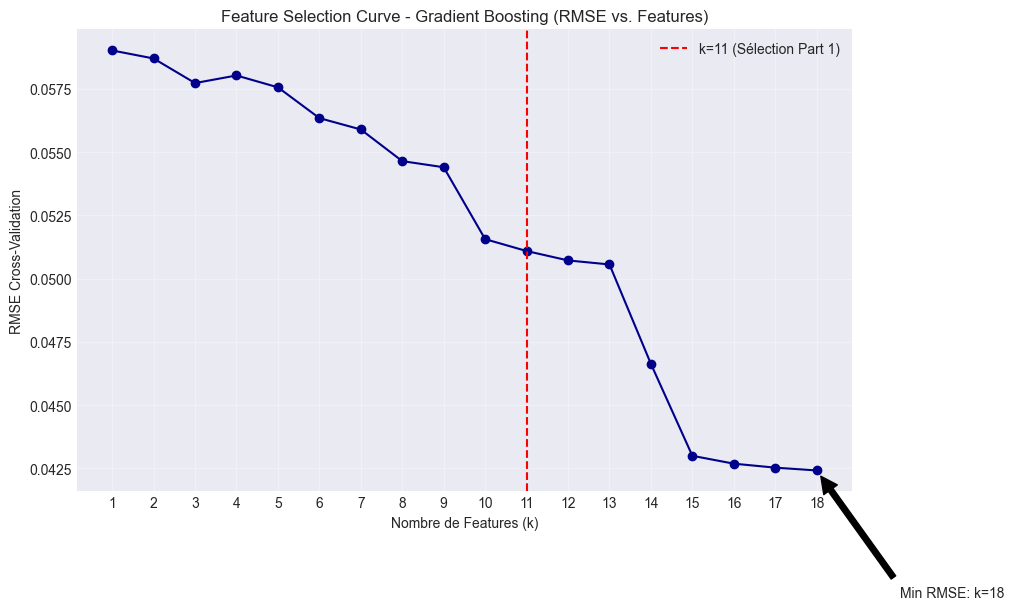

In [ ]:
max_features = 18
n_features_range = np.arange(1, max_features + 1) # Test k de 1 à 18
rmse_scores = []
optimized_model_step = deepcopy(best_model.named_steps['model'])

for k in n_features_range:
    temp_pipeline = Pipeline([
        ('preprocessor', preprocessor), # Raw data -> 18 features
        ('sfs', SelectKBest(score_func=f_regression, k=k)), # Sélectionne k features
        ('model', optimized_model_step) 
    ])

    y_target = y_target_log if best_use_log else y_target_original
    cv_scores = cross_val_score(
        temp_pipeline, 
        X_train, y_target, # X_train est la donnée brute, la pipeline gère le preprocessing
        cv=5, 
        scoring='neg_root_mean_squared_error', 
        n_jobs=-1
    )

    mean_rmse = np.mean(-cv_scores)
    rmse_scores.append(mean_rmse)
    print(f"k={k:2d}: RMSE CV = {mean_rmse:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(n_features_range, rmse_scores, 'o-', color='darkblue')
best_k_idx = np.argmin(rmse_scores)
best_k_found = n_features_range[best_k_idx]
best_rmse_found = rmse_scores[best_k_idx]

# Mettre en évidence le k=11 sélectionné en Part 1
baseline_k_part1 = 11
plt.axvline(x=baseline_k_part1, color='red', linestyle='--', label=f'k={baseline_k_part1} (Sélection Part 1)')

plt.annotate(f'Min RMSE: k={best_k_found}', 
             xy=(best_k_found, best_rmse_found), 
             xytext=(best_k_found+2, best_rmse_found-0.005),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10)

plt.title(f'Feature Selection Curve - {best_model_name} (RMSE vs. Features)')
plt.xlabel('Nombre de Features (k)')
plt.ylabel('RMSE Cross-Validation')
plt.xticks(n_features_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'../results/reports/figures/feature_selection_curve_{best_model_name.replace(" ", "_").lower()}.pdf')
plt.show()

## Comparaison avec baseline

In [8]:
# Comparaison des résultats avec baseline linéaire
if baseline_linear_rmse is not None:
    print(f"\n{'='*70}")
    print(f"Comparaison avec le modèle linéaire polynomial (Part 1):")
    print(f"   RMSE Test Linéaire: {baseline_linear_rmse:.4f}")
    print(f"   RMSE Test Non-Linéaire ({best_model_name}): {best_rmse_test:.4f}")
    improvement = baseline_linear_rmse - best_rmse_test
    improvement_pct = (improvement / baseline_linear_rmse) * 100
    print(f"   Amélioration: {improvement:.4f} ({improvement_pct:.2f}%)")
    print(f"{'='*70}\n")
    


Comparaison avec le modèle linéaire polynomial (Part 1):
   RMSE Test Linéaire: 0.0423
   RMSE Test Non-Linéaire (Gradient Boosting): 0.0418
   Amélioration: 0.0005 (1.18%)



## Sauvegarde du modèle et des prédictions

In [9]:
safe_model_name = best_model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
model_path = f'../results/models/nonlinear_model_{safe_model_name}.pkl'
joblib.dump(best_model, model_path)
print(f"Modèle sauvegardé: {model_path}")

model_info = {
    'model_name': best_model_name,
    'model_type': 'non-linear',
    'use_log_transform': best_use_log,
    'best_params': best_params,
    'rmse_test': best_rmse_test,
    'comparison_with_linear': {
        'linear_rmse': baseline_linear_rmse,
        'improvement_pct': improvement if baseline_linear_rmse is not None else None
    },
    'all_results': results,
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

info_path = '../results/models/nonlinear_model_info_sfs.json'
with open(info_path, 'w') as f:
    json.dump(model_info, f, indent=4, default=str) 
print(f"Métadonnées sauvegardées: {info_path}")

# y_pred.csv
predictions = best_model.predict(X_unlabeled)
predictions = np.maximum(0, predictions)

print(f"Statistiques des prédictions:")
print(f"  Min: {predictions.min():.4f}, Max: {predictions.max():.4f}")
print(f"  Mean: {predictions.mean():.4f}, Std: {predictions.std():.4f}")

final_predictions_df = pd.DataFrame(predictions)
final_predictions_df.to_csv('../results/predictions/y_pred_part2.csv', index=False, header=False)

Modèle sauvegardé: ../results/models/nonlinear_model_gradient_boosting.pkl
Métadonnées sauvegardées: ../results/models/nonlinear_model_info_sfs.json
Statistiques des prédictions:
  Min: 0.0000, Max: 0.4212
  Mean: 0.0841, Std: 0.0719
